In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
from google.colab import files
import pandas as pd

# Upload the file
uploaded = files.upload()

Saving employee_promotion.csv to employee_promotion.csv


In [3]:
df = pd.read_csv('employee_promotion.csv')

In [4]:
df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,0,49.0,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,60.0,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,50.0,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,50.0,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,73.0,0


In [5]:
df.tail()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won,avg_training_score,is_promoted
54803,3030,Technology,region_14,Bachelor's,m,sourcing,1,48,3.0,17,0,78.0,0
54804,74592,Operations,region_27,Master's & above,f,other,1,37,2.0,6,0,56.0,0
54805,13918,Analytics,region_1,Bachelor's,m,other,1,27,5.0,3,0,79.0,0
54806,13614,Sales & Marketing,region_9,NaN,m,sourcing,1,29,1.0,2,0,NaN,0
54807,51526,HR,region_22,Bachelor's,m,other,1,27,1.0,5,0,49.0,0


In [6]:
df.sample(5)

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won,avg_training_score,is_promoted
52189,67065,Sales & Marketing,region_26,Master's & above,m,other,1,32,4.0,7,0,51.0,0
49457,41857,Sales & Marketing,region_30,Bachelor's,m,other,1,41,1.0,14,0,46.0,0
2924,14002,Procurement,region_2,Master's & above,f,other,1,32,3.0,6,0,74.0,0
14507,7933,Procurement,region_20,Bachelor's,m,sourcing,1,35,4.0,9,0,70.0,0
5638,71079,Analytics,region_30,NaN,m,sourcing,1,28,2.0,2,0,84.0,0


In [7]:
df.shape

(54808, 13)

In [8]:
df.columns

Index(['employee_id', 'department', 'region', 'education', 'gender',
       'recruitment_channel', 'no_of_trainings', 'age', 'previous_year_rating',
       'length_of_service', 'awards_won', 'avg_training_score', 'is_promoted'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  awards_won            54808 non-null  int64  
 11  avg_training_score    52248 non-null  float64
 12  is_promoted           54808 non-null  int64  
dtypes: float64(2), int64(6), object(5)
memory usage: 5.4+ MB


In [10]:
df.describe()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,awards_won,avg_training_score,is_promoted
count,54808.000000,54808.000000,54808.000000,50684.000000,54808.000000,54808.000000,52248.000000,54808.000000
mean,39195.830627,1.253011,34.803915,3.329256,5.865512,0.023172,63.712238,0.085170
std,22586.581449,0.609264,7.660169,1.259993,4.265094,0.150450,13.521910,0.279137
min,1.000000,1.000000,20.000000,1.000000,1.000000,0.000000,39.000000,0.000000
25%,19669.750000,1.000000,29.000000,3.000000,3.000000,0.000000,51.000000,0.000000
50%,39225.500000,1.000000,33.000000,3.000000,5.000000,0.000000,60.000000,0.000000
75%,58730.500000,1.000000,39.000000,4.000000,7.000000,0.000000,77.000000,0.000000
max,78298.000000,10.000000,60.000000,5.000000,37.000000,1.000000,99.000000,1.000000


In [11]:
df.describe(include='object')

,department,region,education,gender,recruitment_channel
count,54808,54808,52399,54808,54808
unique,9,34,3,2,3
top,Sales & Marketing,region_2,Bachelor's,m,other
freq,16840,12343,36669,38496,30446


In [12]:
df.isnull().sum()

,0
employee_id,0
department,0
region,0
education,2409
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,4124
length_of_service,0


In [13]:
missing_percent = (df.isnull().sum()/len(df))*100

missing_percent.sort_values(ascending=False)

,0
previous_year_rating,7.524449
avg_training_score,4.670851
education,4.395344
employee_id,0.000000
department,0.000000
gender,0.000000
region,0.000000
no_of_trainings,0.000000
recruitment_channel,0.000000
age,0.000000


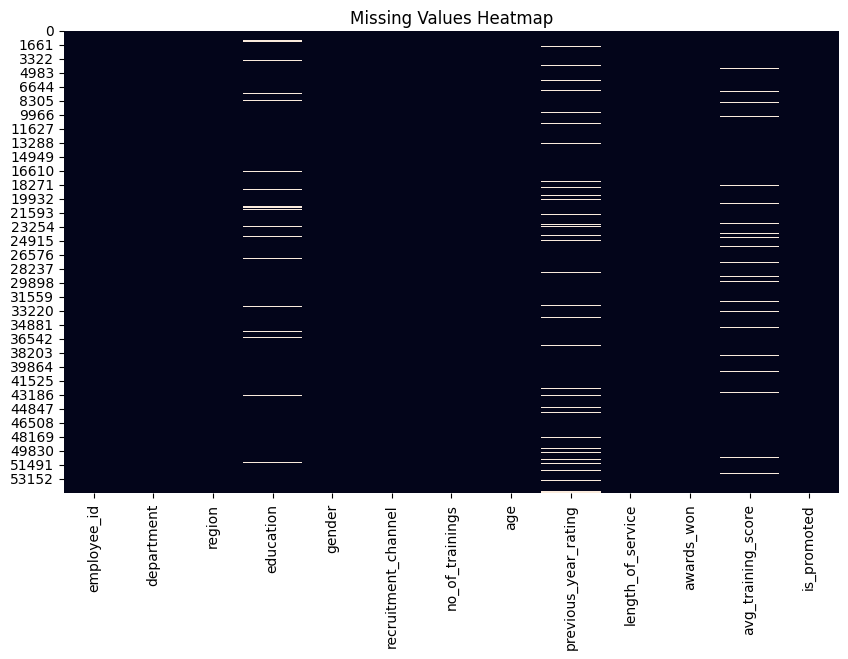

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title('Missing Values Heatmap')
plt.show()

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df[df.duplicated()]

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won,avg_training_score,is_promoted


In [18]:
df['is_promoted'].value_counts()

,count
is_promoted,
0,50140
1,4668


In [19]:
df['is_promoted'].value_counts(normalize=True)*100

,proportion
is_promoted,
0,91.482995
1,8.517005


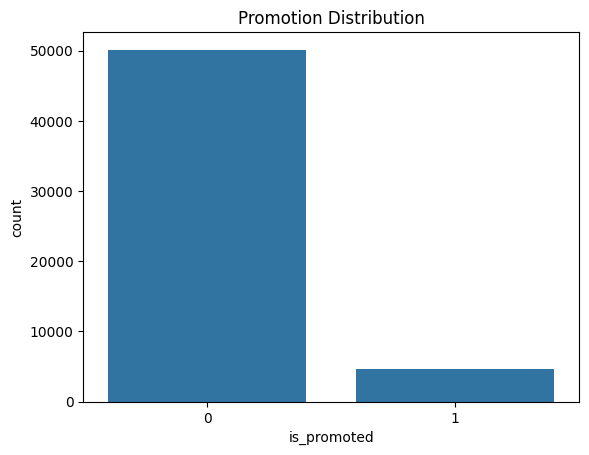

In [20]:
sns.countplot(x='is_promoted', data=df)

plt.title('Promotion Distribution')
plt.show()

In [21]:
numerical_cols = df.select_dtypes(include=np.number).columns

numerical_cols

Index(['employee_id', 'no_of_trainings', 'age', 'previous_year_rating',
       'length_of_service', 'awards_won', 'avg_training_score', 'is_promoted'],
      dtype='object')

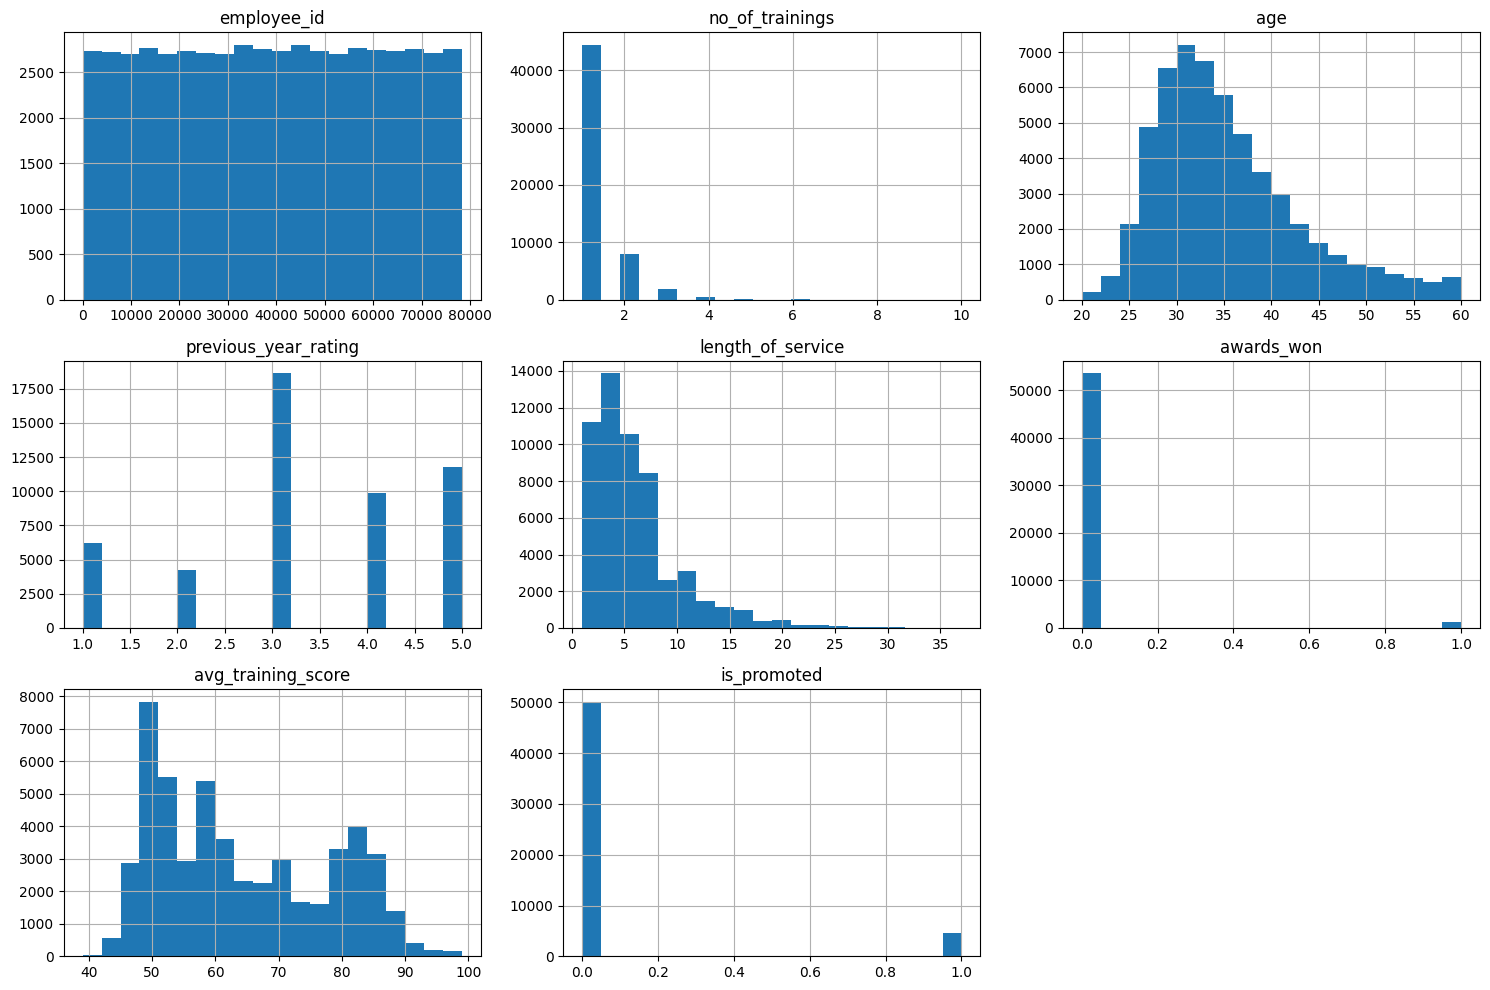

In [22]:
df[numerical_cols].hist(
    figsize=(15,10),
    bins=20
)

plt.tight_layout()
plt.show()

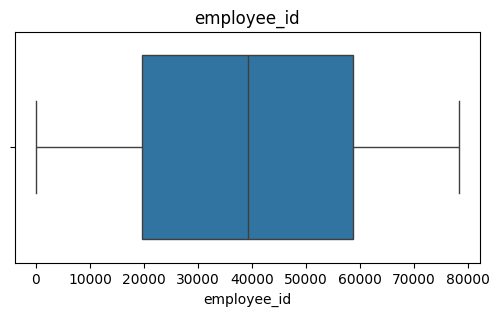

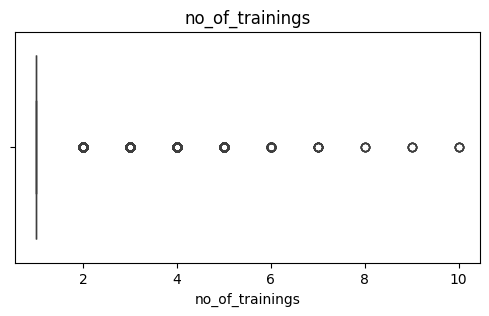

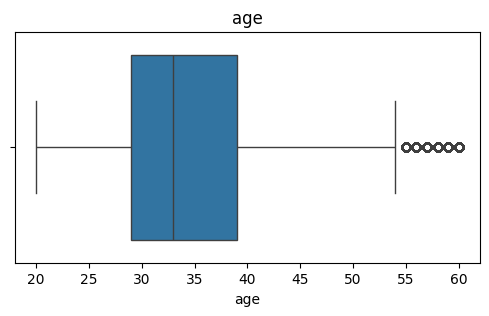

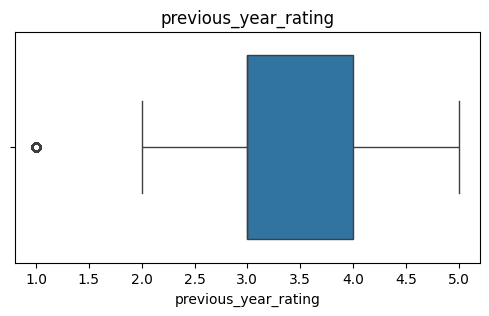

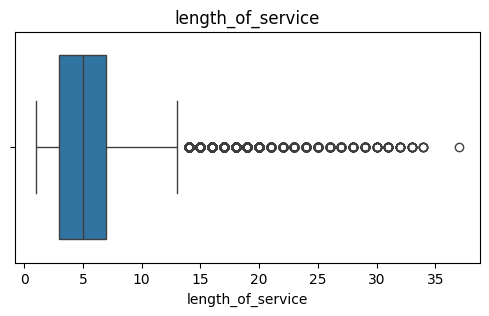

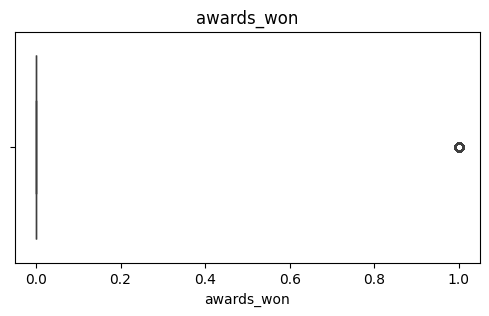

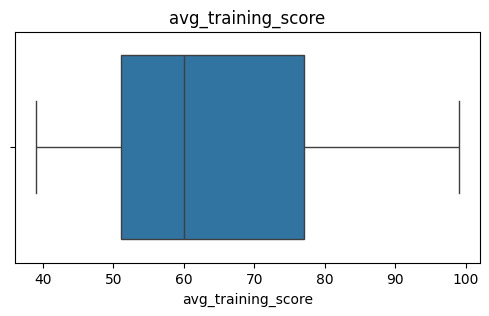

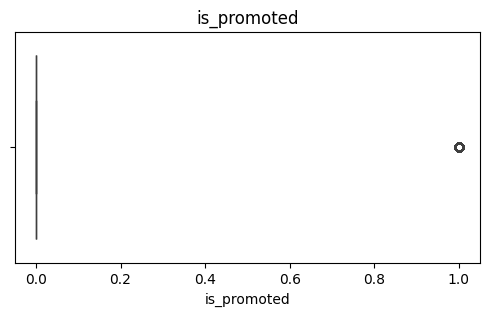

In [23]:
for col in numerical_cols:

    plt.figure(figsize=(6,3))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

In [24]:
categorical_cols = df.select_dtypes(include='object').columns

categorical_cols

Index(['department', 'region', 'education', 'gender', 'recruitment_channel'], dtype='object')

In [25]:
for col in categorical_cols:

    print("\n")
    print(col)

    print(df[col].value_counts())



department
department
Sales & Marketing    16840
Operations           11348
Technology            7138
Procurement           7138
Analytics             5352
Finance               2536
HR                    2418
Legal                 1039
R&D                    999
Name: count, dtype: int64


region
region
region_2     12343
region_22     6428
region_7      4843
region_15     2808
region_13     2648
region_26     2260
region_31     1935
region_4      1703
region_27     1659
region_16     1465
region_28     1318
region_11     1315
region_23     1175
region_29      994
region_32      945
region_19      874
region_20      850
region_14      827
region_25      819
region_17      796
region_5       766
region_6       690
region_30      657
region_8       655
region_10      648
region_1       610
region_24      508
region_12      500
region_9       420
region_21      411
region_3       346
region_34      292
region_33      269
region_18       31
Name: count, dtype: int64


education
educati

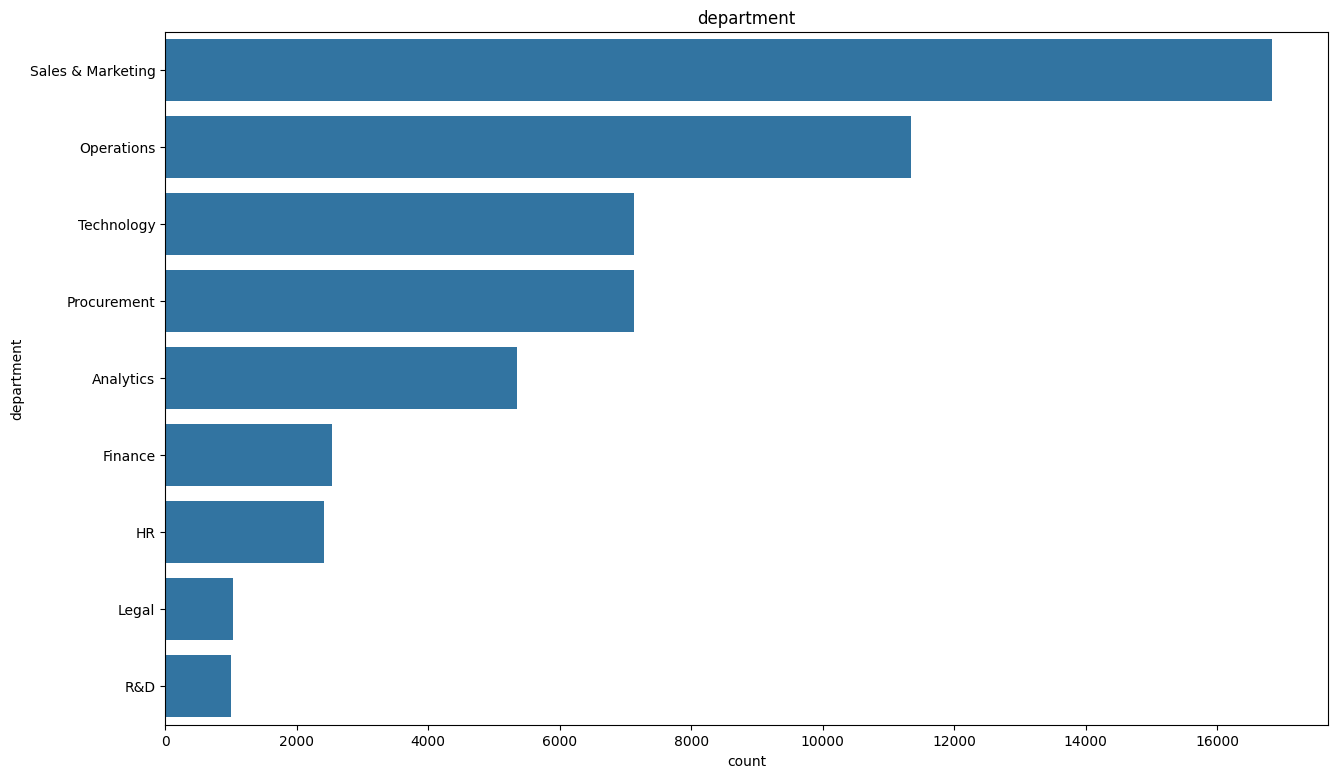

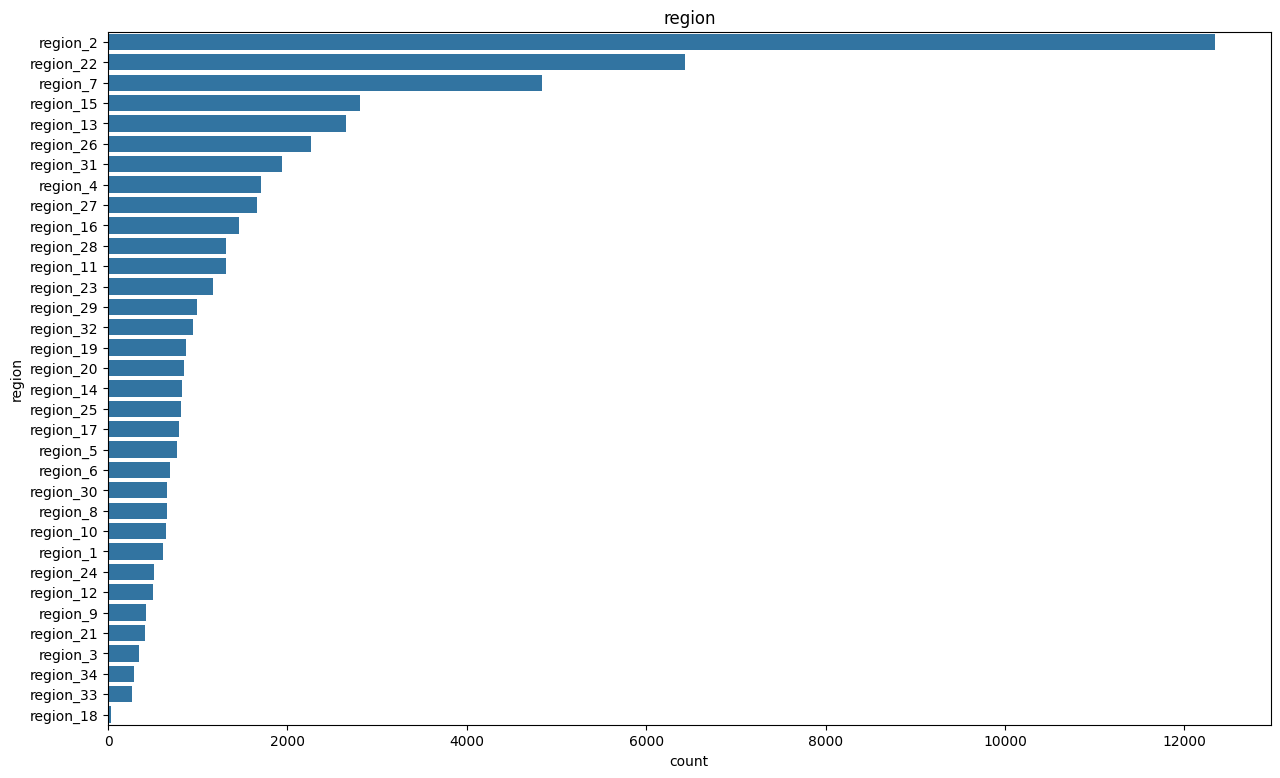

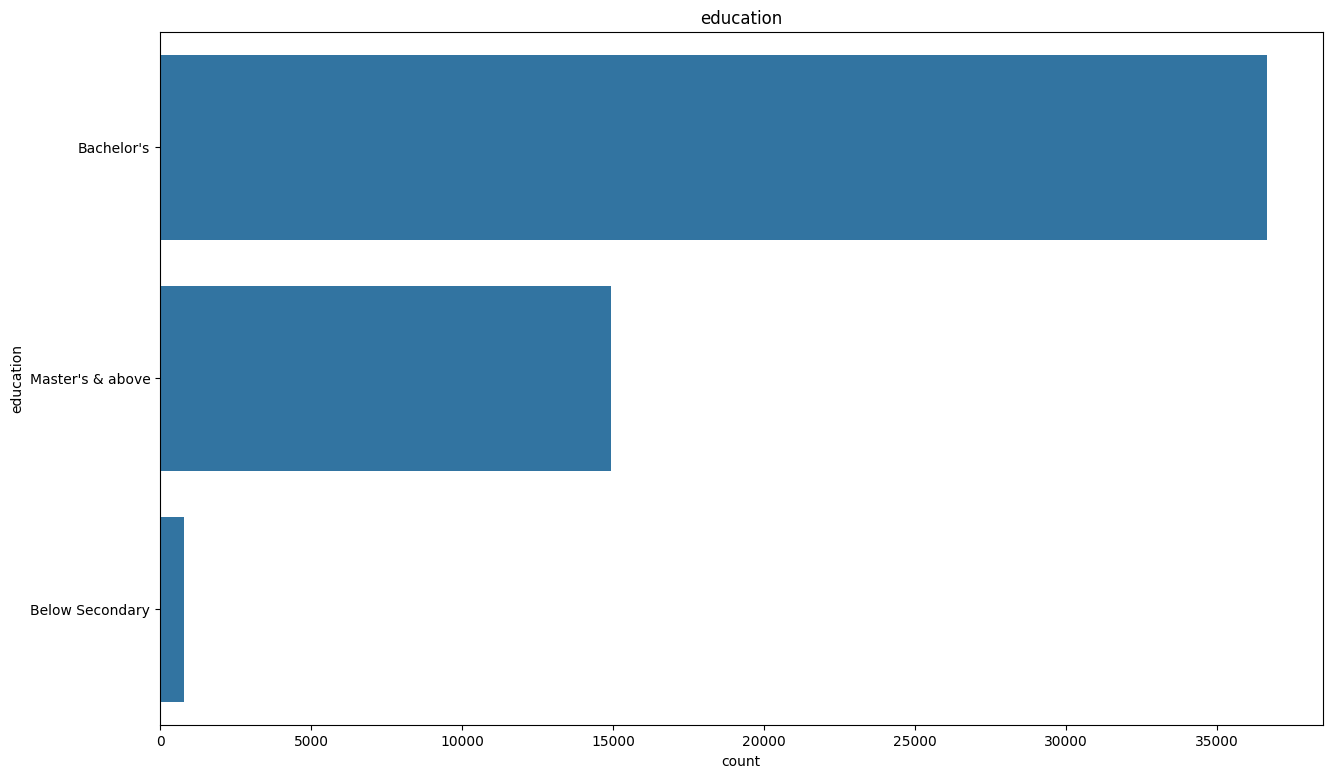

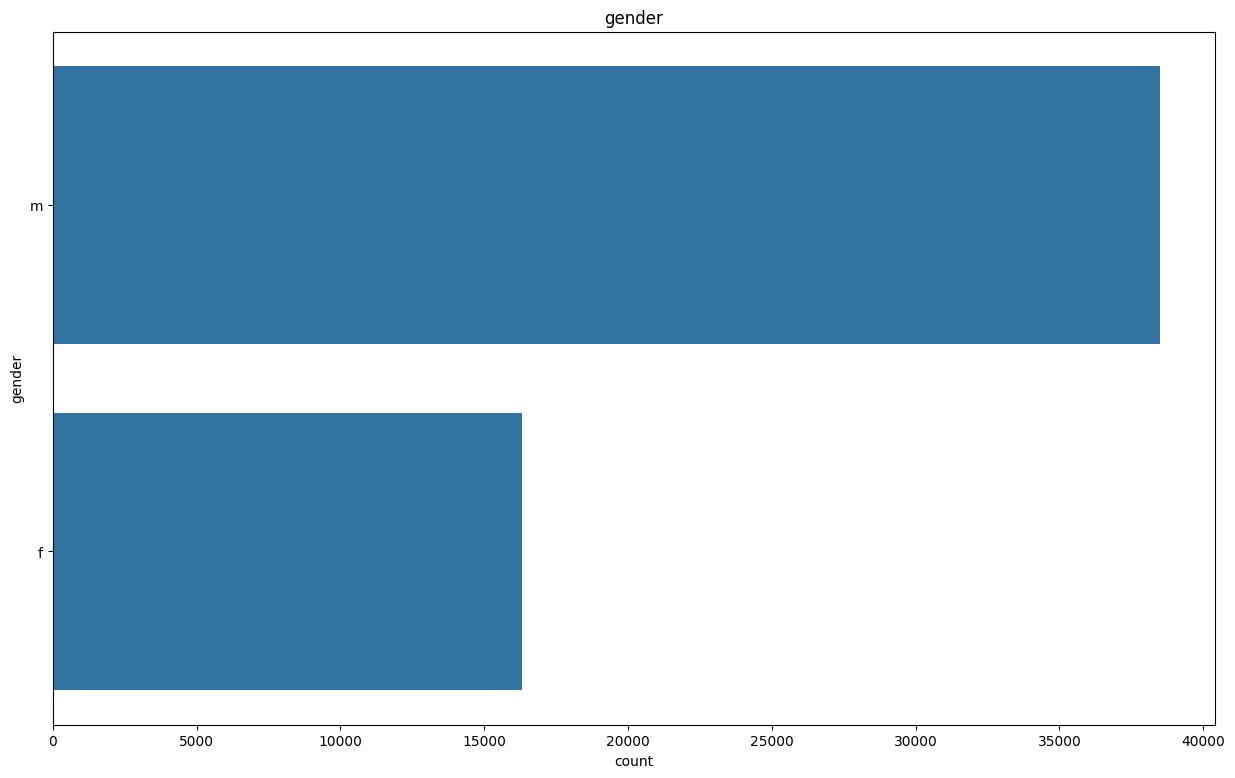

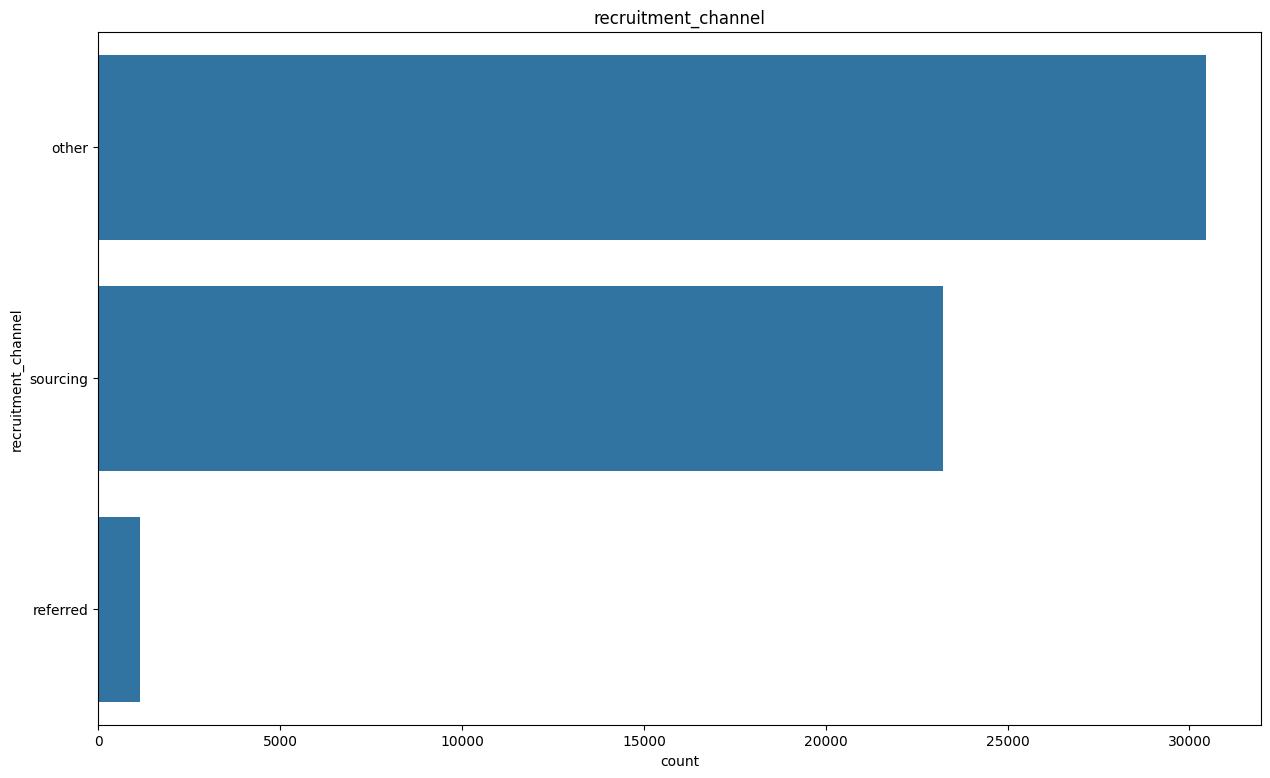

In [26]:
for col in categorical_cols:

    plt.figure(figsize=(15,9))

    sns.countplot(y=col,
                  data=df,
                  order=df[col].value_counts().index)

    plt.title(col)

    plt.show()

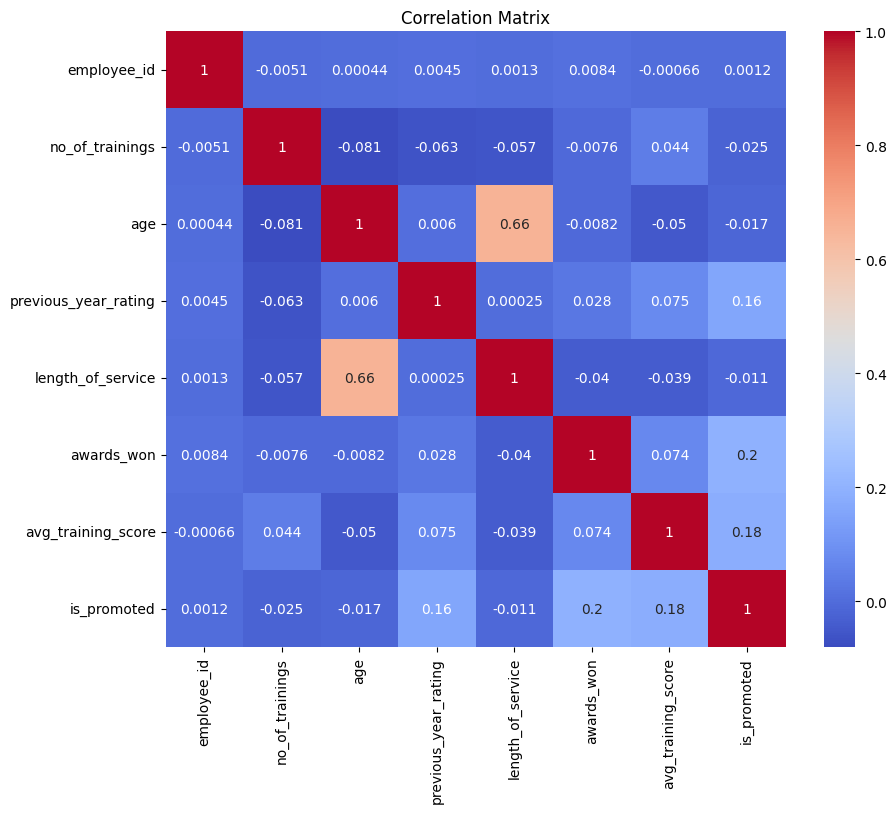

In [27]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()

In [28]:
df.groupby('is_promoted').mean(numeric_only=True)

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,awards_won,avg_training_score
is_promoted,,,,,,,
0,39187.520423,1.257639,34.844037,3.267911,5.879398,0.014180,62.947673
1,39285.092331,1.203299,34.372965,3.986140,5.716367,0.119751,71.842574


In [29]:
pd.crosstab(
    df['department'],
    df['is_promoted']
)

is_promoted,0,1
department,,
Analytics,4840,512
Finance,2330,206
HR,2282,136
Legal,986,53
Operations,10325,1023
Procurement,6450,688
R&D,930,69
Sales & Marketing,15627,1213
Technology,6370,768


In [30]:
promotion_rate = pd.crosstab(
    df['department'],
    df['is_promoted'],
    normalize='index'
)*100

promotion_rate

is_promoted,0,1
department,,
Analytics,90.433483,9.566517
Finance,91.876972,8.123028
HR,94.375517,5.624483
Legal,94.898941,5.101059
Operations,90.985196,9.014804
Procurement,90.361446,9.638554
R&D,93.093093,6.906907
Sales & Marketing,92.796912,7.203088
Technology,89.240684,10.759316


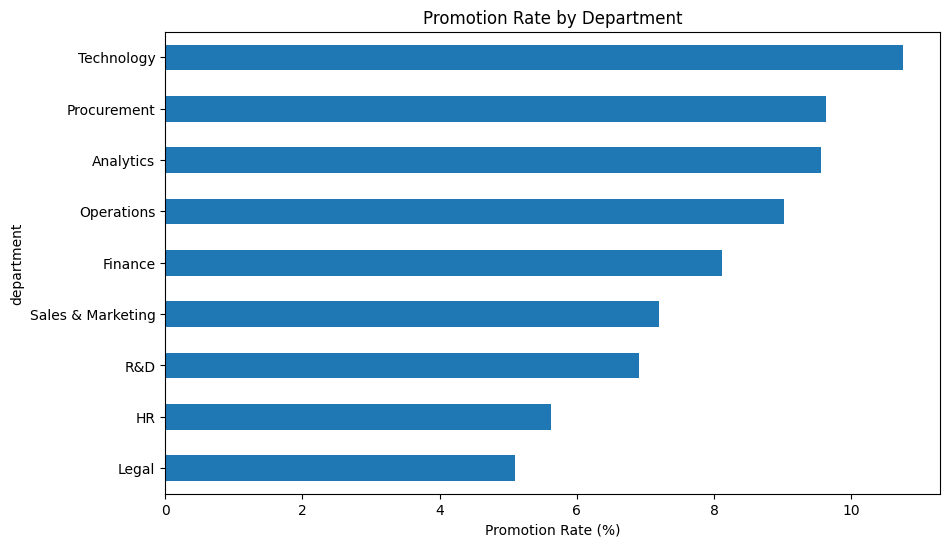

In [31]:
promotion_rate[1].sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.xlabel('Promotion Rate (%)')
plt.title('Promotion Rate by Department')

plt.show()

In [32]:
df.groupby('is_promoted')[[
    'age',
    'previous_year_rating',
    'length_of_service',
    'avg_training_score'
]].mean()

,age,previous_year_rating,length_of_service,avg_training_score
is_promoted,,,,
0,34.844037,3.267911,5.879398,62.947673
1,34.372965,3.986140,5.716367,71.842574




---



---



---



---



---



---



Recommended Next Analysis

Before Data Preparation, we need to discover:

Which variables influence promotion most?

In [33]:
pd.crosstab(
    df['previous_year_rating'],
    df['is_promoted'],
    normalize='index'
)*100

is_promoted,0,1
previous_year_rating,,
1.0,98.585891,1.414109
2.0,95.715976,4.284024
3.0,92.722097,7.277903
4.0,92.062367,7.937633
5.0,83.638532,16.361468


In [34]:
pd.crosstab(
    df['awards_won'],
    df['is_promoted'],
    normalize='index'
)*100

is_promoted,0,1
awards_won,,
0,92.325078,7.674922
1,55.984252,44.015748


In [35]:
pd.crosstab(
    df['gender'],
    df['is_promoted'],
    normalize='index'
)*100

is_promoted,0,1
gender,,
f,91.006621,8.993379
m,91.684850,8.315150


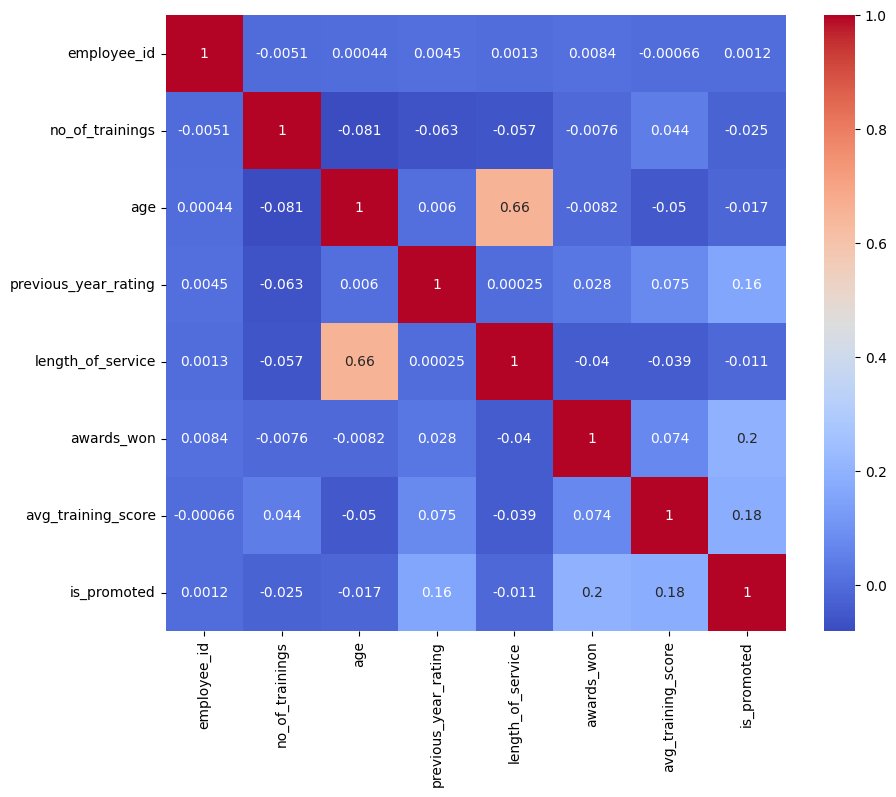

In [36]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [37]:
df.groupby('is_promoted')[[
    'age',
    'length_of_service',
    'previous_year_rating',
    'avg_training_score',
    'no_of_trainings'
]].mean()

,age,length_of_service,previous_year_rating,avg_training_score,no_of_trainings
is_promoted,,,,,
0,34.844037,5.879398,3.267911,62.947673,1.257639
1,34.372965,5.716367,3.986140,71.842574,1.203299


In [38]:
pd.crosstab(
    df['education'],
    df['is_promoted'],
    normalize='index'
)*100

is_promoted,0,1
education,,
Bachelor's,91.796886,8.203114
Below Secondary,91.677019,8.322981
Master's & above,90.144054,9.855946


In [39]:
pd.crosstab(
    df['department'],
    df['is_promoted'],
    normalize='index'
)*100

is_promoted,0,1
department,,
Analytics,90.433483,9.566517
Finance,91.876972,8.123028
HR,94.375517,5.624483
Legal,94.898941,5.101059
Operations,90.985196,9.014804
Procurement,90.361446,9.638554
R&D,93.093093,6.906907
Sales & Marketing,92.796912,7.203088
Technology,89.240684,10.759316


In [40]:
pd.crosstab(
    df['region'],
    df['is_promoted'],
    normalize='index'
)*100

is_promoted,0,1
region,,
region_1,90.491803,9.508197
region_10,92.129630,7.870370
region_11,94.372624,5.627376
region_12,93.400000,6.600000
region_13,91.314199,8.685801
region_14,92.503023,7.496977
region_15,92.094017,7.905983
region_16,93.037543,6.962457
region_17,86.306533,13.693467


In [41]:
df.duplicated().sum()

np.int64(0)

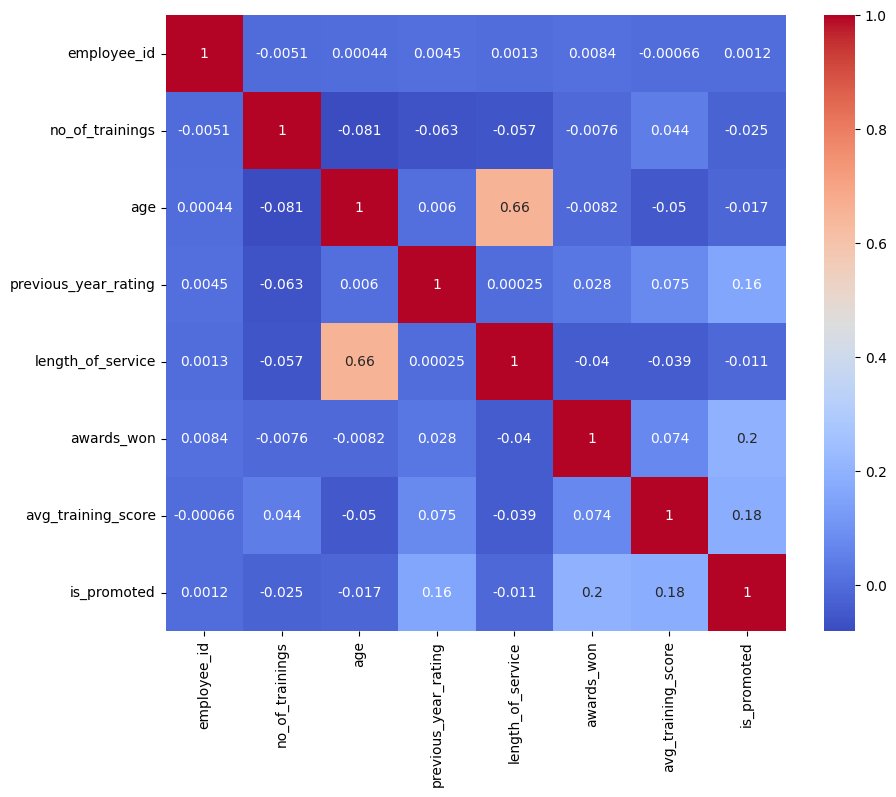

In [42]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [43]:
df = df.drop('employee_id', axis=1)

In [44]:
df.duplicated().sum()

np.int64(220)

In [45]:
df['education'].fillna(
    df['education'].mode()[0],
    inplace=True
)

/tmp/ipykernel_474/2821432363.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['education'].fillna(


In [46]:
df['previous_year_rating'].fillna(
    df['previous_year_rating'].median(),
    inplace=True
)

/tmp/ipykernel_474/1126343940.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['previous_year_rating'].fillna(


In [47]:
df['avg_training_score'].fillna(
    df['avg_training_score'].median(),
    inplace=True
)

/tmp/ipykernel_474/850102452.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['avg_training_score'].fillna(


In [48]:
df.isnull().sum()

,0
department,0
region,0
education,0
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,0
length_of_service,0
awards_won,0


In [49]:
cat_cols = [
    'department',
    'region',
    'education',
    'gender',
    'recruitment_channel'
]

In [50]:
df = pd.get_dummies(
    df,
    columns=cat_cols,
    drop_first=True
)

In [51]:
X = df.drop('is_promoted', axis=1)

y = df['is_promoted']

In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [53]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(43846, 52)
(10962, 52)
(43846,)
(10962,)


In [54]:
y_train.value_counts(normalize=True)*100

,proportion
is_promoted,
0,91.48383
1,8.51617


In [55]:
class_weight='balanced'

In [56]:
df.shape

(54808, 53)

In [57]:
X_train.shape
X_test.shape

(10962, 52)

In [58]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [59]:
y_pred = lr.predict(X_test)

y_prob = lr.predict_proba(X_test)[:,1]

In [60]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.77      0.85     10028
           1       0.21      0.67      0.32       934

    accuracy                           0.76     10962
   macro avg       0.59      0.72      0.59     10962
weighted avg       0.90      0.76      0.81     10962



In [61]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[7706 2322]
 [ 310  624]]


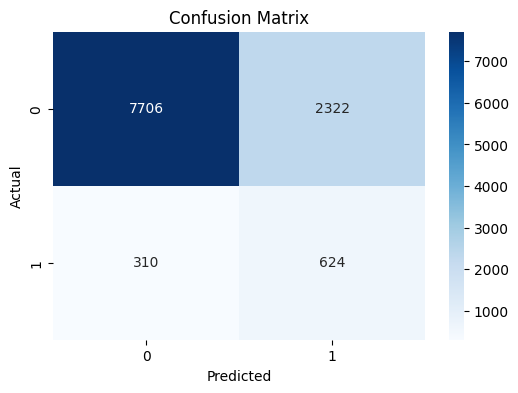

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

In [63]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.7972375955461752


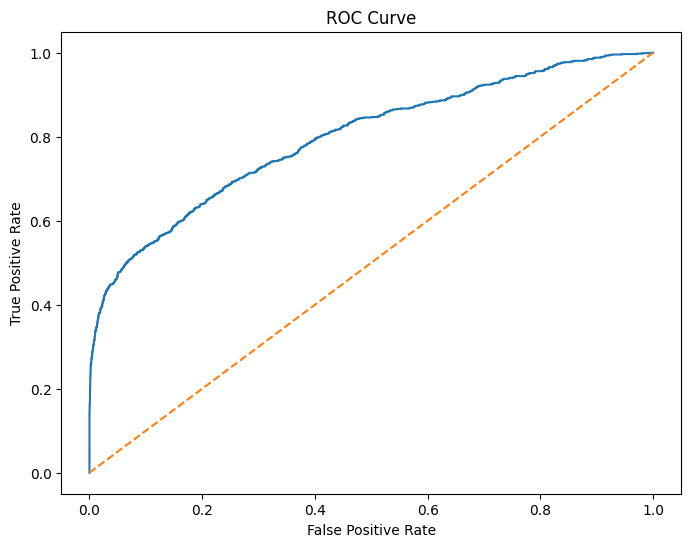

In [64]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr)

plt.plot([0,1],[0,1],'--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

plt.show()

In [65]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0]
})

coef_df = coef_df.sort_values(
    by='Coefficient',
    ascending=False
)

coef_df.head(20)

,Feature,Coefficient
12,department_Sales & Marketing,5.384081
7,department_HR,4.956866
9,department_Operations,3.946460
6,department_Finance,3.625610
8,department_Legal,3.434252
10,department_Procurement,2.433429
4,awards_won,1.751374
13,department_Technology,0.998653
2,previous_year_rating,0.510922
30,region_region_25,0.422261


In [66]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

y_prob_rf = rf.predict_proba(X_test)[:,1]

In [67]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_rf
))

              precision    recall  f1-score   support

           0       0.94      0.99      0.96     10028
           1       0.81      0.27      0.40       934

    accuracy                           0.93     10962
   macro avg       0.87      0.63      0.68     10962
weighted avg       0.93      0.93      0.92     10962



In [68]:
from sklearn.metrics import roc_auc_score

roc_auc_score(
    y_test,
    y_prob_rf
)

np.float64(0.7785231864697477)

In [69]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df.head(20)

,Feature,Importance
5,avg_training_score,0.243019
1,age,0.150878
3,length_of_service,0.121605
2,previous_year_rating,0.107059
51,recruitment_channel_sourcing,0.031557
4,awards_won,0.030089
0,no_of_trainings,0.027463
49,gender_m,0.027071
12,department_Sales & Marketing,0.021089
48,education_Master's & above,0.018681


In [70]:
!pip install xgboost

In [71]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    scale_pos_weight=10
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

y_prob_xgb = xgb.predict_proba(X_test)[:,1]

In [72]:
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score

print(classification_report(y_test, y_pred_xgb))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_xgb))

              precision    recall  f1-score   support

           0       0.96      0.86      0.91     10028
           1       0.30      0.62      0.40       934

    accuracy                           0.84     10962
   macro avg       0.63      0.74      0.65     10962
weighted avg       0.90      0.84      0.87     10962

ROC-AUC: 0.8182539638476932


In [73]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

In [74]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

In [75]:
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5]
}

In [76]:
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=20,
    scoring='roc_auc',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 5, 7, 9],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [100, 200, 300, 500],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='roc_auc', verbose=2)

In [77]:
print(random_search.best_params_)

{'subsample': 1.0, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.2, 'colsample_bytree': 0.9}


In [78]:
print(random_search.best_score_)

0.8178937659420218


In [79]:
best_xgb = random_search.best_estimator_

best_xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [80]:
y_pred_best = best_xgb.predict(X_test)

y_prob_best = best_xgb.predict_proba(X_test)[:,1]

In [81]:
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score

print(classification_report(
    y_test,
    y_pred_best
))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_best))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97     10028
           1       0.94      0.33      0.49       934

    accuracy                           0.94     10962
   macro avg       0.94      0.66      0.73     10962
weighted avg       0.94      0.94      0.93     10962

ROC-AUC: 0.822201582891245


In [82]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_xgb.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df.head(20)

,Feature,Importance
4,awards_won,0.131821
12,department_Sales & Marketing,0.130931
9,department_Operations,0.111591
5,avg_training_score,0.081731
6,department_Finance,0.069558
2,previous_year_rating,0.064038
10,department_Procurement,0.039602
7,department_HR,0.031878
11,department_R&D,0.026040
27,region_region_22,0.019298


# Employee Promotion Prediction

Business Objective:
The objective of this project was to develop a machine learning model capable of predicting whether an employee is likely to be promoted based on demographic, educational, performance, and organizational factors.

Dataset:
The dataset contained 54,808 employee records with 13 original variables, including department, education, region, previous performance ratings, training information, awards, and promotion status.

Target Variable:
is_promoted

Methodology:
The project followed the Data Science methodology:

1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Exploratory Data Analysis
5. Feature Engineering
6. Model Development
7. Model Evaluation
8. Hyperparameter Optimization

Models Evaluated:

* Logistic Regression
* Random Forest
* XGBoost
* Tuned XGBoost

Results:
The Tuned XGBoost model achieved the best overall business performance with:

* Accuracy: 94%
* Precision: 94%
* Recall: 33%
* F1 Score: 49%
* ROC-AUC: 0.822

Key Findings:
The most influential factors affecting promotion decisions were:

* Awards Won
* Average Training Score
* Previous Year Rating
* Department
* Region
* Education Level

Conclusion:
The Tuned XGBoost model is recommended for deployment as a decision-support tool for HR promotion planning. The model provides highly reliable promotion recommendations and can assist management in identifying high-potential employees while reducing subjectivity in promotion decisions.


In [83]:
y_pred = (y_prob > 0.50).astype(int)

In [84]:
y_prob = best_xgb.predict_proba(X_test)[:,1]

In [85]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

f1_scores = 2 * (precision * recall) / (precision + recall)

best_index = np.argmax(f1_scores)

best_threshold = thresholds[best_index]

print("Best Threshold:", best_threshold)
print("Best F1 Score:", f1_scores[best_index])

Best Threshold: 0.25064912
Best F1 Score: 0.5256756756756756


In [86]:
y_pred_opt = (y_prob >= best_threshold).astype(int)

In [87]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_opt
))

              precision    recall  f1-score   support

           0       0.95      0.98      0.97     10028
           1       0.71      0.42      0.53       934

    accuracy                           0.94     10962
   macro avg       0.83      0.70      0.75     10962
weighted avg       0.93      0.94      0.93     10962



In [88]:
f1_scores = np.nan_to_num(
    2 * (precision * recall) / (precision + recall)
)

In [89]:
!pip install shap

In [90]:
import shap

In [91]:
explainer = shap.TreeExplainer(best_xgb)

shap_values = explainer.shap_values(X_test)

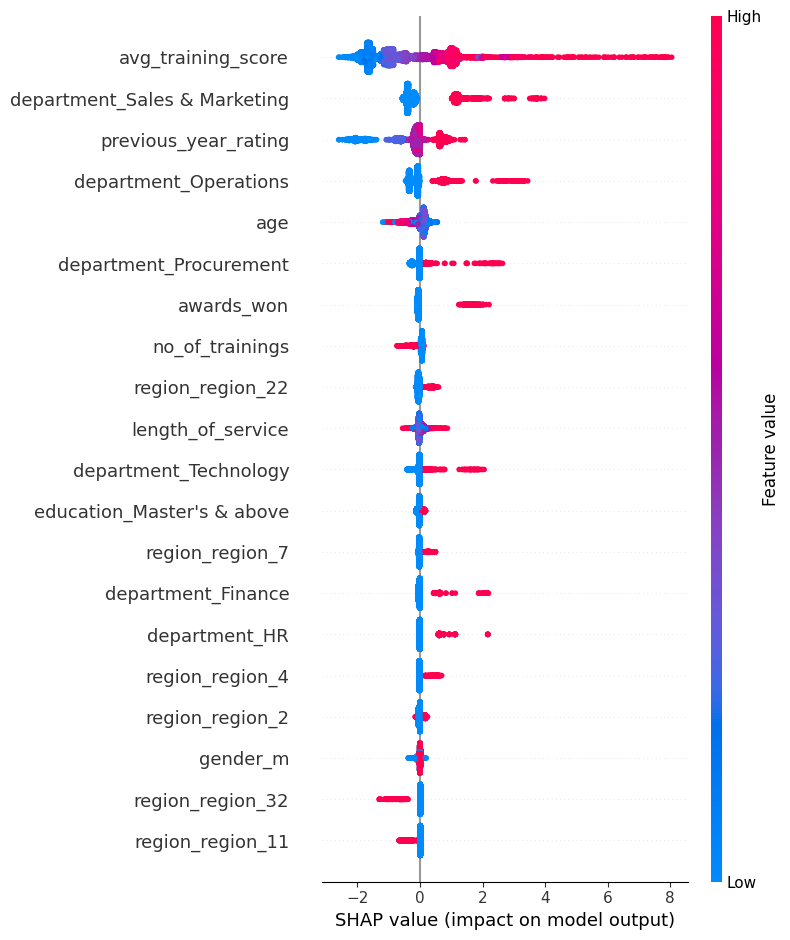

In [92]:
shap.summary_plot(
    shap_values,
    X_test
)

In [93]:
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0]
)

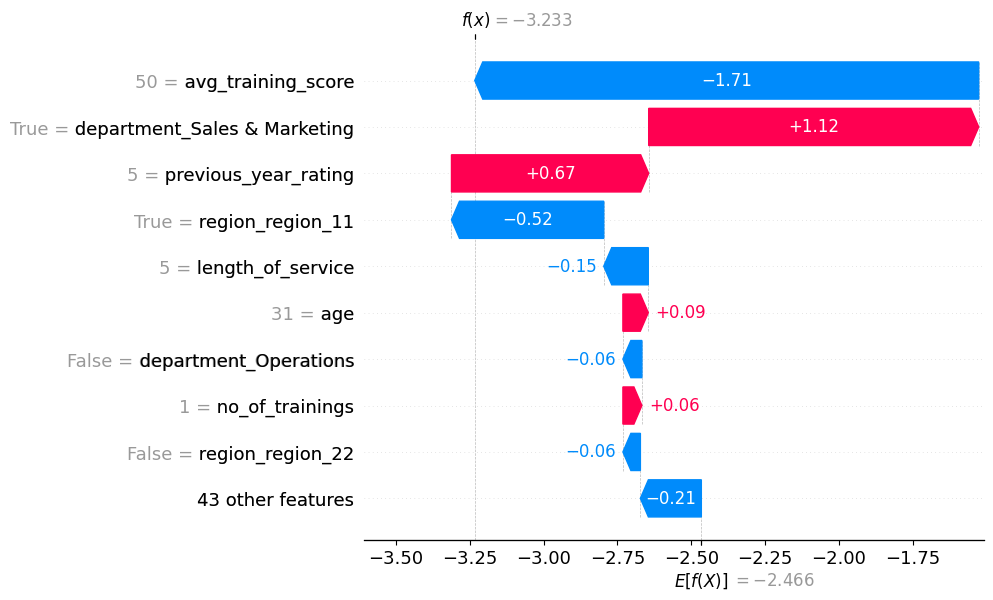

In [94]:
import shap

explainer = shap.TreeExplainer(best_xgb)

shap_values = explainer(X_test)

shap.plots.waterfall(shap_values[0])

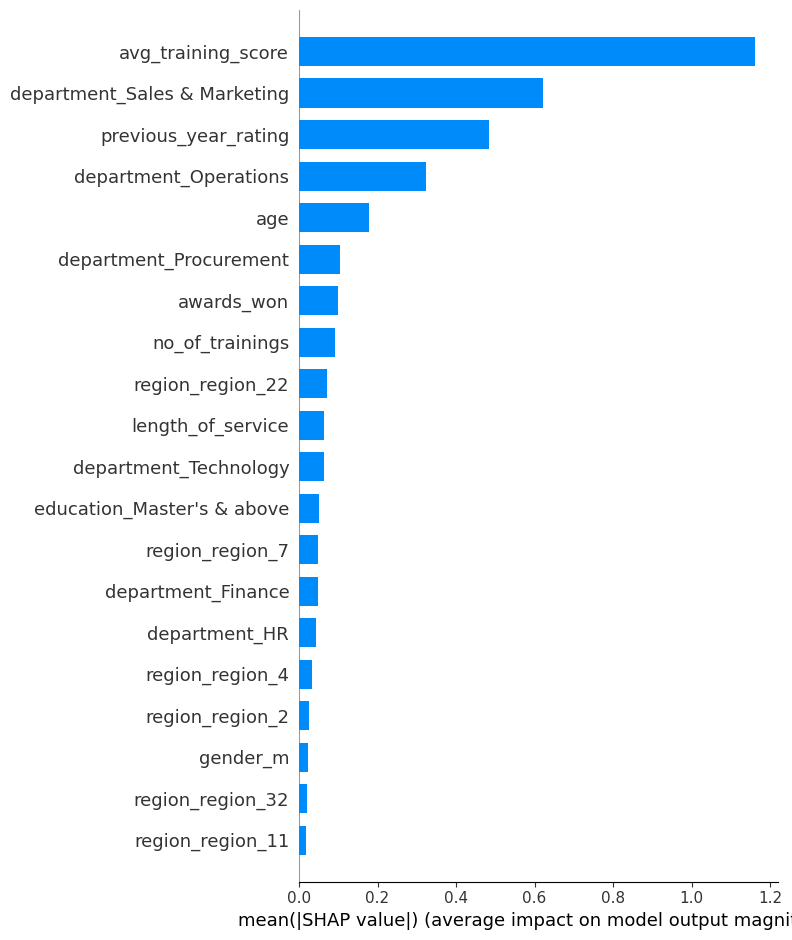

In [95]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type='bar'
)

In [96]:
import pandas as pd
import numpy as np

shap_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': np.abs(shap_values.values).mean(axis=0)
})

shap_importance.sort_values(
    by='Importance',
    ascending=False
).head(20)

,Feature,Importance
5,avg_training_score,1.161714
12,department_Sales & Marketing,0.622078
2,previous_year_rating,0.484368
9,department_Operations,0.323367
1,age,0.178702
10,department_Procurement,0.104442
4,awards_won,0.098206
0,no_of_trainings,0.090687
27,region_region_22,0.072631
3,length_of_service,0.064146


In [97]:
shap_importance.sort_values(
    by='Importance',
    ascending=False
).head(20)

,Feature,Importance
5,avg_training_score,1.161714
12,department_Sales & Marketing,0.622078
2,previous_year_rating,0.484368
9,department_Operations,0.323367
1,age,0.178702
10,department_Procurement,0.104442
4,awards_won,0.098206
0,no_of_trainings,0.090687
27,region_region_22,0.072631
3,length_of_service,0.064146


In [98]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier
import numpy as np

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    best_xgb,
    X,
    y,
    cv=cv,
    scoring='roc_auc'
)

print(scores)
print("Mean ROC-AUC:", scores.mean())
print("Std:", scores.std())


[0.81552611 0.80700244 0.82835438 0.83565085 0.81185783]
Mean ROC-AUC: 0.8196783207669874
Std: 0.010672157294005055


In [99]:
important_features = shap_importance[
    shap_importance['Importance'] > 0.02
]

important_features

,Feature,Importance
0,no_of_trainings,0.090687
1,age,0.178702
2,previous_year_rating,0.484368
3,length_of_service,0.064146
4,awards_won,0.098206
5,avg_training_score,1.161714
6,department_Finance,0.049633
7,department_HR,0.044206
9,department_Operations,0.323367
10,department_Procurement,0.104442


In [100]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 80.0 MB/s eta 0:00:00


In [101]:
import streamlit as st

st.title("Employee Promotion Predictor")

age = st.number_input("Age")
rating = st.number_input("Previous Rating")
score = st.number_input("Training Score")

if st.button("Predict"):
    prediction = best_xgb.predict(...)
    st.write(prediction)

2026-06-14 04:01:14.405 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-14 04:01:14.621 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-06-14 04:01:14.622 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-14 04:01:14.624 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-14 04:01:14.624 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-14 04:01:14.625 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-14 04:01:14.626 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-14 04:01:14.627 Thread 'MainThread': mi

In [102]:
import joblib

joblib.dump(best_xgb,
            'employee_promotion_model.pkl')

['employee_promotion_model.pkl']

In [103]:
joblib.dump(X.columns,
            'feature_columns.pkl')

['feature_columns.pkl']

In [104]:
from fastapi import FastAPI

In [105]:
{
  "age": 35,
  "previous_year_rating": 5,
  "avg_training_score": 90
}

{'age': 35, 'previous_year_rating': 5, 'avg_training_score': 90}

In [106]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    best_xgb,
    X,
    y,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

print("Fold Scores:", scores)
print("Mean ROC-AUC:", np.mean(scores))
print("Standard Deviation:", np.std(scores))

Fold Scores: [0.81552611 0.80700244 0.82835438 0.83565085 0.81185783]
Mean ROC-AUC: 0.8196783207669874
Standard Deviation: 0.010672157294005055


In [107]:
selected_features = shap_importance[
    shap_importance['Importance'] > 0.05
]

selected_features

,Feature,Importance
0,no_of_trainings,0.090687
1,age,0.178702
2,previous_year_rating,0.484368
3,length_of_service,0.064146
4,awards_won,0.098206
5,avg_training_score,1.161714
9,department_Operations,0.323367
10,department_Procurement,0.104442
12,department_Sales & Marketing,0.622078
13,department_Technology,0.063261


In [108]:
import joblib

joblib.dump(best_xgb,
            'employee_promotion_model.pkl')

joblib.dump(X.columns.tolist(),
            'feature_columns.pkl')

['feature_columns.pkl']

In [109]:
import joblib

joblib.dump(best_xgb, 'employee_promotion_model.pkl')

print("Model Saved")

Model Saved


In [110]:
joblib.dump(
    X.columns.tolist(),
    'feature_columns.pkl'
)

print("Features Saved")

Features Saved


In [111]:
%%writefile app.py
print("Hello Streamlit")

Writing app.py


In [112]:
!ls

app.py			employee_promotion_model.pkl  sample_data
employee_promotion.csv	feature_columns.pkl


In [113]:
!pip install streamlit

In [114]:
!streamlit run app.py &>/content/logs.txt &

In [115]:
!npm install localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼
added 22 packages in 3s
⠼
⠼3 packages are looking for funding
⠼  run `npm fund` for details
⠼

In [116]:
!pkill -f streamlit
!pkill -f cloudflared
!pkill -f localtunnel

In [117]:
%%writefile app.py

import streamlit as st

st.title("Test App")

st.write("Hello Nematullah")

Overwriting app.py


In [118]:
!streamlit run app.py &>/content/logs.txt &

In [119]:
!cat logs.txt

In [120]:
from google.colab import output
output.serve_kernel_port_as_window(8501)

Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

In [121]:
%%writefile requirements.txt
streamlit
pandas
numpy
scikit-learn
xgboost
joblib

Writing requirements.txt


In [122]:
!cat requirements.txt

streamlit
pandas
numpy
scikit-learn
xgboost
joblib


In [123]:
import joblib

joblib.dump(best_xgb,'employee_promotion_model.pkl')
joblib.dump(X.columns.tolist(),'feature_columns.pkl')

['feature_columns.pkl']

In [124]:
from google.colab import files

files.download('employee_promotion_model.pkl')
files.download('feature_columns.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [125]:
import streamlit as st
import pandas as pd
import joblib

model = joblib.load("employee_promotion_model.pkl")
columns = joblib.load("feature_columns.pkl")

st.title("Employee Promotion Prediction System")

st.header("Employee Information")

age = st.slider("Age",20,60,35)

previous_year_rating = st.slider(
    "Previous Year Rating",
    1,
    5,
    3
)

avg_training_score = st.slider(
    "Average Training Score",
    40,
    100,
    60
)

length_of_service = st.slider(
    "Length of Service",
    1,
    30,
    5
)

awards_won = st.selectbox(
    "Awards Won",
    [0,1]
)

no_of_trainings = st.slider(
    "Number of Trainings",
    1,
    10,
    2
)

if st.button("Predict Promotion"):

    input_df = pd.DataFrame(
        0,
        index=[0],
        columns=columns
    )

    input_df["age"] = age
    input_df["previous_year_rating"] = previous_year_rating
    input_df["avg_training_score"] = avg_training_score
    input_df["length_of_service"] = length_of_service
    input_df["awards_won"] = awards_won
    input_df["no_of_trainings"] = no_of_trainings

    probability = model.predict_proba(input_df)[0][1]

    st.subheader(
        f"Promotion Probability: {probability:.2%}"
    )

    if probability >= 0.25:
        st.success(
            "Likely to be Promoted"
        )
    else:
        st.error(
            "Unlikely to be Promoted"
        )

2026-06-14 04:01:30.181 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-14 04:01:30.182 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-14 04:01:30.183 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-14 04:01:30.184 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-14 04:01:30.185 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-14 04:01:30.186 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-14 04:01:30.186 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-14 04:01:30.188 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [126]:
!cat app.py


import streamlit as st

st.title("Test App")

st.write("Hello Nematullah")


In [127]:
from google.colab import files

files.download("app.py")
files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [128]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

# Load model and feature columns
model = joblib.load("employee_promotion_model.pkl")
columns = joblib.load("feature_columns.pkl")

st.title("Employee Promotion Prediction System")

age = st.slider("Age", 20, 60, 35)

previous_year_rating = st.slider(
    "Previous Year Rating",
    1,
    5,
    3
)

avg_training_score = st.slider(
    "Average Training Score",
    40,
    100,
    60
)

length_of_service = st.slider(
    "Length of Service",
    1,
    30,
    5
)

awards_won = st.selectbox(
    "Awards Won",
    [0,1]
)

no_of_trainings = st.slider(
    "Number of Trainings",
    1,
    10,
    2
)

if st.button("Predict Promotion"):

    input_df = pd.DataFrame(
        0,
        index=[0],
        columns=columns
    )

    input_df["age"] = age
    input_df["previous_year_rating"] = previous_year_rating
    input_df["avg_training_score"] = avg_training_score
    input_df["length_of_service"] = length_of_service
    input_df["awards_won"] = awards_won
    input_df["no_of_trainings"] = no_of_trainings

    probability = model.predict_proba(input_df)[0][1]

    st.subheader("Prediction Result")

    st.write(
        f"Promotion Probability: {probability:.2%}"
    )

    if probability >= 0.25:
        st.success("Likely To Be Promoted")
    else:
        st.error("Unlikely To Be Promoted")

Overwriting app.py


In [129]:
with open("app.py","r") as f:
    print(f.read())


import streamlit as st
import pandas as pd
import joblib

# Load model and feature columns
model = joblib.load("employee_promotion_model.pkl")
columns = joblib.load("feature_columns.pkl")

st.title("Employee Promotion Prediction System")

age = st.slider("Age", 20, 60, 35)

previous_year_rating = st.slider(
    "Previous Year Rating",
    1,
    5,
    3
)

avg_training_score = st.slider(
    "Average Training Score",
    40,
    100,
    60
)

length_of_service = st.slider(
    "Length of Service",
    1,
    30,
    5
)

awards_won = st.selectbox(
    "Awards Won",
    [0,1]
)

no_of_trainings = st.slider(
    "Number of Trainings",
    1,
    10,
    2
)

if st.button("Predict Promotion"):

    input_df = pd.DataFrame(
        0,
        index=[0],
        columns=columns
    )

    input_df["age"] = age
    input_df["previous_year_rating"] = previous_year_rating
    input_df["avg_training_score"] = avg_training_score
    input_df["length_of_service"] = length_of_service
    input_

In [130]:
!cat app.py


import streamlit as st
import pandas as pd
import joblib

# Load model and feature columns
model = joblib.load("employee_promotion_model.pkl")
columns = joblib.load("feature_columns.pkl")

st.title("Employee Promotion Prediction System")

age = st.slider("Age", 20, 60, 35)

previous_year_rating = st.slider(
    "Previous Year Rating",
    1,
    5,
    3
)

avg_training_score = st.slider(
    "Average Training Score",
    40,
    100,
    60
)

length_of_service = st.slider(
    "Length of Service",
    1,
    30,
    5
)

awards_won = st.selectbox(
    "Awards Won",
    [0,1]
)

no_of_trainings = st.slider(
    "Number of Trainings",
    1,
    10,
    2
)

if st.button("Predict Promotion"):

    input_df = pd.DataFrame(
        0,
        index=[0],
        columns=columns
    )

    input_df["age"] = age
    input_df["previous_year_rating"] = previous_year_rating
    input_df["avg_training_score"] = avg_training_score
    input_df["length_of_service"] = length_of_service
    input_

In [131]:
from google.colab import files

files.download("app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [132]:
!pkill -f streamlit

In [133]:
!streamlit run app.py &>/content/logs.txt &

In [ ]:
!npx localtunnel --port 8501

⠙your url is: https://quiet-humans-start.loca.lt
